We want to sample from $\exp(-\|x\| - c \|x\|^2 / 2)$, for some small constant $c$. 

We have 
$$V(x) = \|x\| + c \|x\|^2 / 2$$
$$\nabla V(x) = \frac{x}{\|x\|} + c x$$
$$\nabla V^\star(x) = \frac{1}{c} x -  \frac{x}{\|x\|}$$

$$\nabla^2 V(x) = \frac{I}{\|x\|} - \frac{x x^\top}{\|x\|^3}  + c I$$


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd
import math

In [11]:
SMALL_SIZE = 18
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE) 


lts = ['-', '--', '-.',':', '-']


steps = ['0.1']
d=2

names = ['CLs.npy',
'CNs.npy',
'CTs.npy',
'YLs.npy',
'YNs.npy',
'YTs.npy',
'mLs.npy',
'mNs.npy',
'mTs.npy']

def mean_dist_true(m_true, Y):
    d, n = Y.shape
    running_mean = Y[:, 0]
    conv = np.zeros(n)
    conv[0] = np.power(np.linalg.norm(running_mean - m_true), 2)
    for i in range(n-1):
        running_mean = (i+1) * running_mean / (i+2) + (1) * Y[:, i] / (i+2)
        conv[i+1] = np.power(np.linalg.norm(running_mean - m_true), 2)
    return conv

sm = 10
x0 = 1000 * np.ones(d,) / math.sqrt(2)

In [12]:
YNs = np.load('Lap_0.1' + '/' + 'YNs.npy')

d, N, reps = YNs.shape
N2 = sm * N
convL = np.zeros((1+sm * N, len(steps)))
convN = np.zeros((1+N, len(steps)))
convM = np.zeros((1+N, len(steps)))
convT = np.zeros((1+sm * N, len(steps)))
i = 0

convL[0,:] = np.ones(len(steps),) * np.power(np.linalg.norm(x0), 2)
convN[0,:] = np.ones(len(steps),) * np.power(np.linalg.norm(x0), 2)
convM[0,:] = np.ones(len(steps),) * np.power(np.linalg.norm(x0), 2)
convT[0,:] = np.ones(len(steps),) * np.power(np.linalg.norm(x0), 2)

for s in steps:
    YNs = np.load('Lap_' + s + '/' + 'YNs.npy')
    YMs = np.load('Lap_' + s + '/' + 'YMs.npy')
    YLs = np.load('Lap_' + s + '/' + 'YLs.npy')
    YTs = np.load('Lap_' + s + '/' + 'YTs.npy')
    
    for r in range(reps):
        print(r)
        convN[1:, i] += mean_dist_true(np.zeros((d,)), YNs[:,:,r]) / reps
        convM[1:, i] += mean_dist_true(np.zeros((d,)), YMs[:,:,r]) / reps
        convL[1:, i] += mean_dist_true(np.zeros((d,)), YLs[:,:,r]) / reps
        convT[1:, i] += mean_dist_true(np.zeros((d,)), YTs[:,:,r]) / reps
    
    i += 1
    
np.save('plot_data/convN_mean.npy', convN)
np.save('plot_data/convM_mean.npy', convM)
np.save('plot_data/convL_mean.npy', convL)
np.save('plot_data/convT_mean.npy', convT)    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


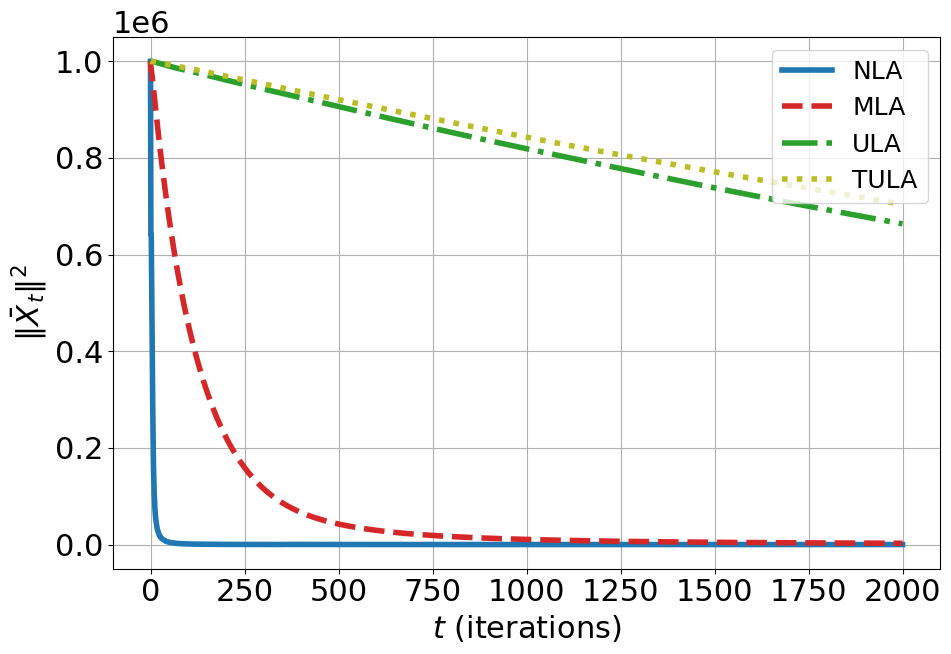

In [13]:
convN = np.load('plot_data/convN_mean.npy')
convM = np.load('plot_data/convM_mean.npy')
convL = np.load('plot_data/convL_mean.npy')
convT = np.load('plot_data/convT_mean.npy')
N = 2000
p, ax = plt.subplots(figsize = (10, 7))

colors = ['tab:blue',  "tab:orange", "tab:olive", "tab:purple"]
i = 0
idx = [0]
for i in idx: #range(len(steps)):
    s = steps[i]
    ax.plot((convN[0:1*N,i]), color = 'tab:blue', linestyle = lts[0], label = r'NLA', linewidth = 4)
    ax.plot((convM[0:1*N,i]), color = 'tab:red', linestyle = lts[1], label = r'MLA', linewidth = 4)
    ax.plot((convL[0:1*N,i]), color = 'tab:green', linestyle = lts[2], label = r'ULA', linewidth = 4)
    ax.plot((convT[0:1*N,i]), color = 'tab:olive', linestyle = lts[3], label = r'TULA', linewidth = 4)
    
    i += 1
    
handles, labels = ax.get_legend_handles_labels() 
ax.legend(loc = 'upper right')
plt.xlabel(r'$t$ (iterations)')    
plt.ylabel(r'$\|\bar X_t\|^2$')   
ax.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.tight_layout()

plt.savefig('plots/lap_mean_iters_full.pdf')



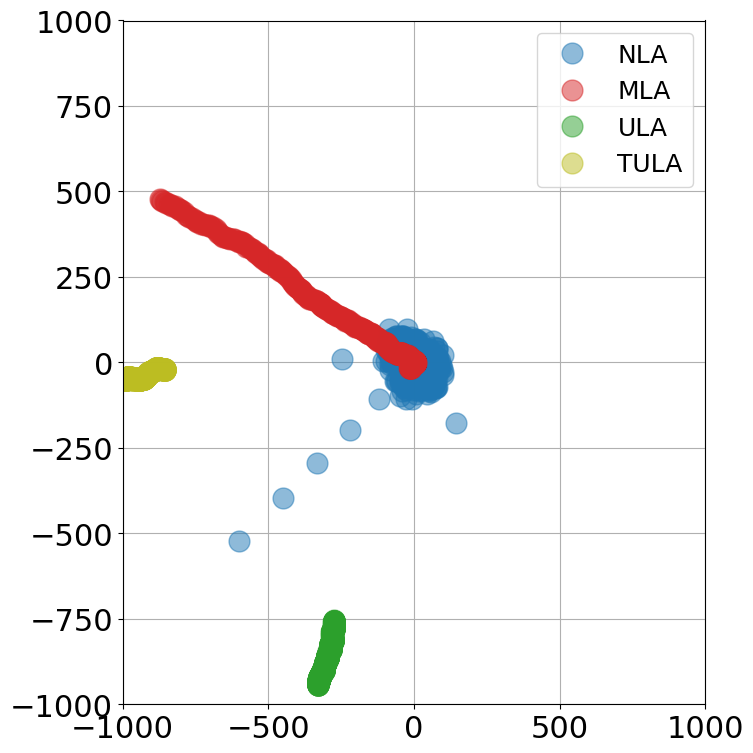

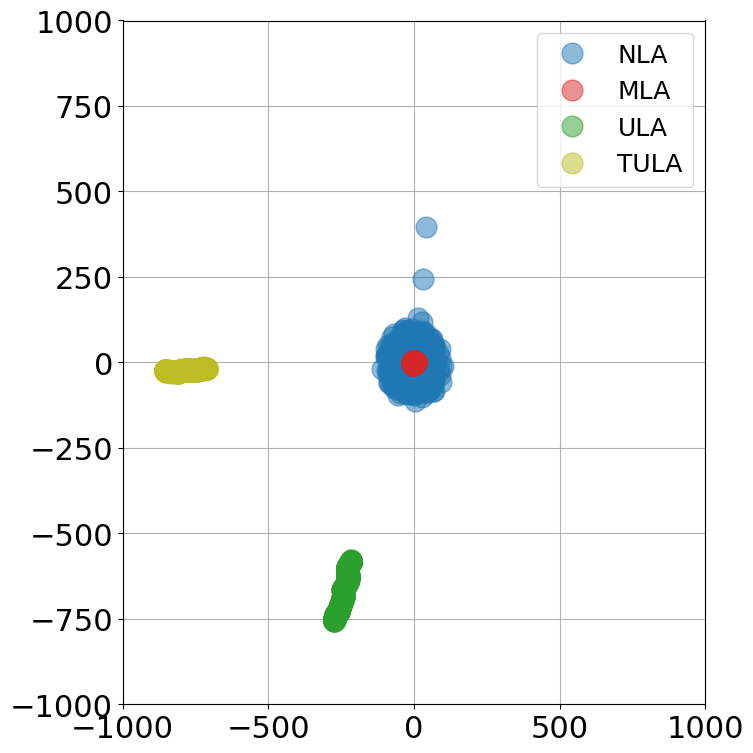

In [15]:
YNs = np.load('Lap_' + '0.1' + '/' + 'YNs.npy')
YMs = np.load('Lap_' + '0.1' + '/' + 'YMs.npy')
YLs = np.load('Lap_' + '0.1' + '/' + 'YLs.npy')
YTs = np.load('Lap_' + '0.1' + '/' + 'YTs.npy')

plt.figure(figsize=(8, 8))
plt.plot(YNs[0,:1000,0], YNs[1,:1000,0], 'o', color = 'tab:blue', markersize = 15, alpha = 0.5)
plt.plot(YMs[0,:1000,0], YMs[1,:1000,0], 'o', color = 'tab:red', markersize = 15, alpha = 0.5)
plt.plot(YLs[0,:1000,0], YLs[1,:1000,0], 'o', color = 'tab:green', markersize = 15, alpha = 0.5)
plt.plot(YTs[0,:1000,0], YTs[1,:1000,0], 'o', color = 'tab:olive', markersize = 15, alpha = 0.5)
plt.xlim([-1000, 1000])
plt.ylim([-1000, 1000])
plt.grid()
plt.tight_layout()

plt.legend(['NLA', 'MLA', 'ULA', 'TULA'])
plt.savefig('plots/lap_samples_first_stage.pdf')

plt.figure(figsize=(8, 8))
plt.plot(YNs[0,1000:2000,0], YNs[1,1000:2000,0], 'o', color = 'tab:blue', markersize = 15, alpha = 0.5)
plt.plot(YMs[0,1000:2000,0], YMs[1,1000:2000,0], 'o', color = 'tab:red', markersize = 15, alpha = 0.5)
plt.plot(YLs[0,1000:2000,0], YLs[1,1000:2000,0], 'o', color = 'tab:green', markersize = 15, alpha = 0.5)
plt.plot(YTs[0,1000:2000,0], YTs[1,1000:2000,0], 'o', color = 'tab:olive', markersize = 15, alpha = 0.5)
plt.xlim([-1000, 1000])
plt.ylim([-1000, 1000])
plt.grid()
plt.tight_layout()

plt.legend(['NLA', 'MLA', 'ULA', 'TULA'])
plt.savefig('plots/lap_samples_second_stage.pdf')

In [17]:
YNs = np.load('Lap_' + '0.1' + '/' + 'YNs.npy')

d, N, reps = YNs.shape
N2 = sm * N
N = 1000
convL = np.zeros((N, len(steps)))
convN = np.zeros((N, len(steps)))
convM = np.zeros((N, len(steps)))
convT = np.zeros((N, len(steps)))
i = 0

convL[0,:] = np.ones(len(steps),) * np.power(np.linalg.norm(x0), 2)
convN[0,:] = np.ones(len(steps),) * np.power(np.linalg.norm(x0), 2)
convM[0,:] = np.ones(len(steps),) * np.power(np.linalg.norm(x0), 2)
convT[0,:] = np.ones(len(steps),) * np.power(np.linalg.norm(x0), 2)

for s in steps:
    YNs = np.load('Lap_' + s + '/' + 'YNs.npy')
    YMs = np.load('Lap_' + s + '/' + 'YMs.npy')
    YLs = np.load('Lap_' + s + '/' + 'YLs.npy')
    YTs = np.load('Lap_' + s + '/' + 'YTs.npy')
    
    for r in range(reps):
        print(r)
        convN[1:, i] += mean_dist_true(np.zeros((d,)), YNs[:,:N-1,r]) / reps
        convM[1:, i] += mean_dist_true(np.zeros((d,)), YMs[:,:N-1,r]) / reps
        convL[1:, i] += mean_dist_true(np.zeros((d,)), YLs[:,:N-1,r]) / reps
        convT[1:, i] += mean_dist_true(np.zeros((d,)), YTs[:,:N-1,r]) / reps
    
    i += 1
    
np.save('plot_data/convN_mean_first_stage.npy', convN)
np.save('plot_data/convM_mean_first_stage.npy', convM)
np.save('plot_data/convL_mean_first_stage.npy', convL)
np.save('plot_data/convT_mean_first_stage.npy', convT) 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [18]:
YNs = np.load('Lap_' + '0.1' + '/' + 'YNs.npy')

d, N, reps = YNs.shape
N2 = sm * N
N = 1000
convL = np.zeros((N, len(steps)))
convN = np.zeros((N, len(steps)))
convM = np.zeros((N, len(steps)))
convT = np.zeros((N, len(steps)))
i = 0

# convL[0,:] = np.ones(len(steps),) * np.power(np.linalg.norm(), 2)
# convN[0,:] = np.ones(len(steps),) * np.power(np.linalg.norm(x0), 2)
# convM[0,:] = np.ones(len(steps),) * np.power(np.linalg.norm(x0), 2)
# convT[0,:] = np.ones(len(steps),) * np.power(np.linalg.norm(x0), 2)

for s in steps:
    YNs = np.load('Lap_' + s + '/' + 'YNs.npy')
    YMs = np.load('Lap_' + s + '/' + 'YMs.npy')
    YLs = np.load('Lap_' + s + '/' + 'YLs.npy')
    YTs = np.load('Lap_' + s + '/' + 'YTs.npy')
    
    for r in range(reps):
        print(r)
        convN[:, i] += mean_dist_true(np.zeros((d,)), YNs[:,N:2*N,r]) / reps
        convM[:, i] += mean_dist_true(np.zeros((d,)), YMs[:,N:2*N,r]) / reps
        convL[:, i] += mean_dist_true(np.zeros((d,)), YLs[:,N:2*N,r]) / reps
        convT[:, i] += mean_dist_true(np.zeros((d,)), YTs[:,N:2*N,r]) / reps
    
    i += 1
    
np.save('plot_data/convN_mean_second_stage.npy', convN)
np.save('plot_data/convM_mean_second_stage.npy', convM)
np.save('plot_data/convL_mean_second_stage.npy', convL)
np.save('plot_data/convT_mean_second_stage.npy', convT) 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


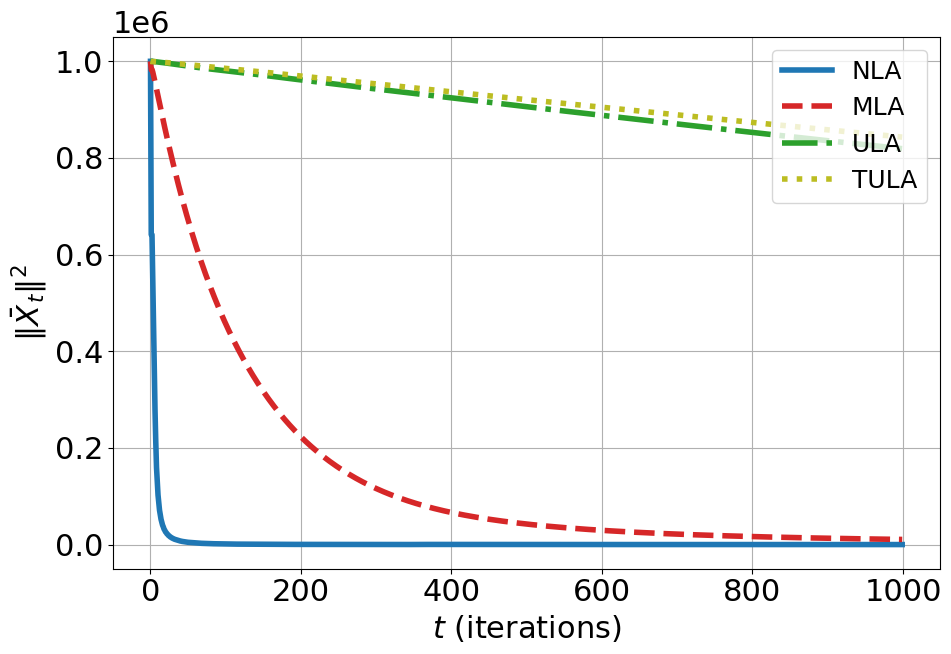

In [20]:
convN = np.load('plot_data/convN_mean_first_stage.npy')
convM = np.load('plot_data/convM_mean_first_stage.npy')
convL = np.load('plot_data/convL_mean_first_stage.npy')
convT = np.load('plot_data/convT_mean_first_stage.npy')

p, ax = plt.subplots(figsize = (10, 7))

colors = ['tab:blue',  "tab:orange", "tab:olive", "tab:purple"]
i = 0
idx = [0]
for i in idx: #range(len(steps)):
    s = steps[i]
    ax.plot((convN[0:N,i]), color = 'tab:blue', linestyle = lts[0], label = r'NLA', linewidth = 4)
    ax.plot((convM[0:N,i]), color = 'tab:red', linestyle = lts[1], label = r'MLA', linewidth = 4)
    ax.plot((convL[0:N,i]), color = 'tab:green', linestyle = lts[2], label = r'ULA', linewidth = 4)
    ax.plot((convT[0:N,i]), color = 'tab:olive', linestyle = lts[3], label = r'TULA', linewidth = 4)
    
    i += 1
    
handles, labels = ax.get_legend_handles_labels() 
ax.legend(loc = 'upper right')
plt.xlabel(r'$t$ (iterations)')    
plt.ylabel(r'$\|\bar X_t\|^2$')   
ax.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.tight_layout()

plt.savefig('plots/lap_mean_first_stage.pdf')



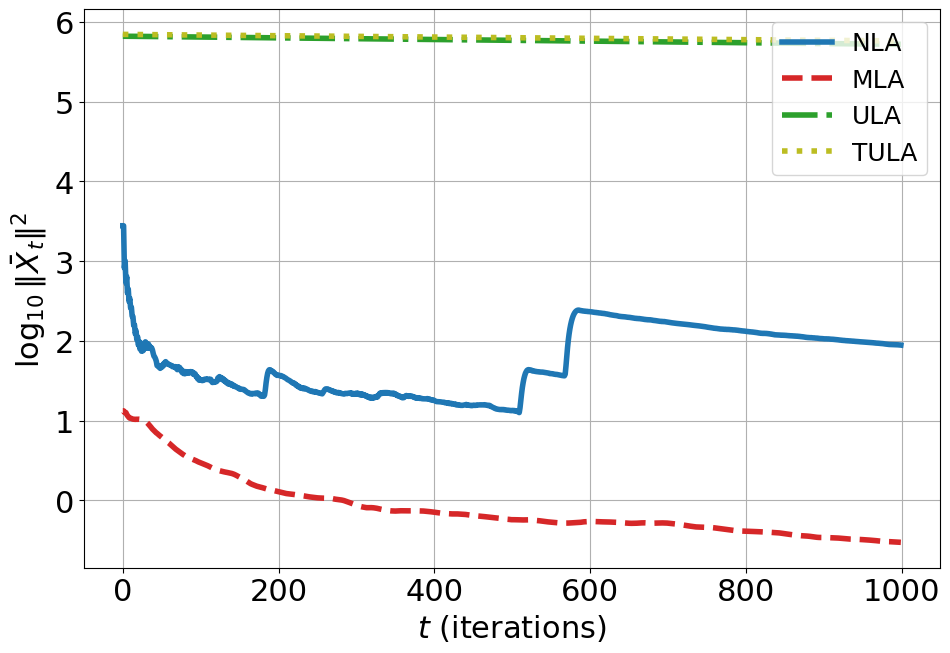

In [22]:
convN = np.load('plot_data/convN_mean_second_stage.npy')
convM = np.load('plot_data/convM_mean_second_stage.npy')
convL = np.load('plot_data/convL_mean_second_stage.npy')
convT = np.load('plot_data/convT_mean_second_stage.npy')

p, ax = plt.subplots(figsize = (10, 7))

colors = ['tab:blue',  "tab:orange", "tab:olive", "tab:purple"]
i = 0
idx = [0]
for i in idx: #range(len(steps)):
    s = steps[i]
    ax.plot(np.log10(convN[0:N,i]), color = 'tab:blue', linestyle = lts[0], label = r'NLA', linewidth = 4)
    ax.plot(np.log10(convM[0:N,i]), color = 'tab:red', linestyle = lts[1], label = r'MLA', linewidth = 4)
    ax.plot(np.log10(convL[0:N,i]), color = 'tab:green', linestyle = lts[2], label = r'ULA', linewidth = 4)
    ax.plot(np.log10(convT[0:N,i]), color = 'tab:olive', linestyle = lts[3], label = r'TULA', linewidth = 4)
    
    i += 1
    
handles, labels = ax.get_legend_handles_labels() 
ax.legend(loc = 'upper right')
plt.xlabel(r'$t$ (iterations)')    
plt.ylabel(r'$\log_{10} \|\bar X_t\|^2$')   
ax.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.tight_layout()

plt.savefig('plots/lap_mean_second_stage.pdf')

